In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import torch
import torch.utils.data
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

In [20]:
# this is a transform to normalize these images
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.1307,], std=[0.3081,])
])

# Download and load the train and test data
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
print()
print(f"MNIST training data loaded: {len(train_dataset)} samples")
print(f"MNIST test data loaded: {len(test_dataset)} samples")


MNIST training data loaded: 60000 samples
MNIST test data loaded: 10000 samples


In [21]:
# # Subset the filtered training data to 25% of its size
# total_size = len(train_dataset)
# subset_size = total_size // 4

# # Generate random indices for the subset
# all_indices = list(range(total_size))
# random.shuffle(all_indices) # this is in place (who knew?!)
# subset_indices = all_indices[:subset_size]

# # Create the subset
# train_dataset_subset = torch.utils.data.Subset(train_dataset, subset_indices)

# print(f"Original training size: {total_size}")
# print(f"New 25% subset training size: {len(train_dataset_subset)}")

# # Re-assign to train_dataset to use in the existing training loop
# train_dataset = train_dataset_subset

Index: 11595


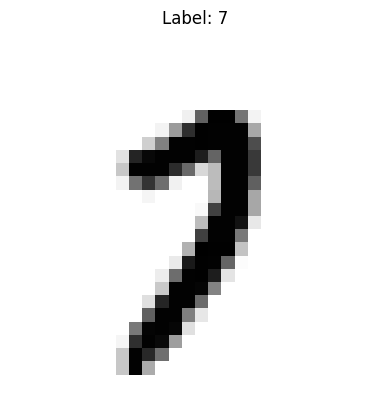

In [22]:
# visualize our input data
def plot_random_train_image(dataset=train_dataset):

    # get random index
    idx = random.randint(0, len(dataset) - 1)
    image, label = dataset[idx]
    print(f"Index: {idx}")

    # Unnormalize for visualization
    # The original transform was Normalize(mean=[0.1307], std=[0.3081])
    # Formula: unnormalized = (normalized * std) + mean
    mean = 0.1307
    std = 0.3081
    unnormalized_image = image * std + mean

    plt.imshow(unnormalized_image.squeeze(), cmap='gray_r')
    plt.title(f'Label: {label}')
    plt.axis('off')
    plt.show()

# Plot a random sample from the filtered training data
plot_random_train_image()

In [23]:
# create a CNN class
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Layer 1: 1 input channel (grayscale), 32 output channels, 3x3 kernel
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=1, padding='same')
        # Layer 2: 32 input channels, 64 output channels, 3x3 kernel
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=1, padding='same')

        # Max pooling layer
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Dropout to prevent overfitting
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)

        # Fully connected layers
        # After two 2x2 poolings, a 28x28 image becomes 7x7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # First Conv block: Conv -> ReLU -> Pool
        x = F.relu(self.conv1(x))
        x = self.pool(x)

        # Second Conv block: Conv -> ReLU -> Pool
        x = F.relu(self.conv2(x))
        x = self.pool(x)

        # Flatten the 3D tensor into a 1D vector for the FC layers
        x = torch.flatten(x, 1)

        # Fully connected layers with Dropout
        x = self.dropout1(x)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)

        # We return raw logits (CrossEntropyLoss in PyTorch applies Softmax internally)
        return x

In [24]:
seed = 499
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)

In [25]:
# Create data loaders for CNN using the binary filtered datasets
batch_size = 128
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=len(test_dataset), shuffle=False)

# Initialize the model
model = SimpleCNN()

# Define Loss function and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Lists for tracking metrics
train_losses_batch, val_losses = [], []
train_accuracies_batch, val_accuracies = [], []

# Training loop
epochs = 3

for epoch in range(epochs):
    # --- TRAINING PHASE ---
    batch_no = 0
    model.train()

    for data, target in train_loader:
        batch_no += 1
        train_loss_batch = 0
        train_correct_batch = 0

        optimizer.zero_grad()
        output = model(data)

        # calculate loss and backprop
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        train_loss_batch += loss.item()

        # calculate accuracy
        probs = torch.softmax(output, dim=1) # convert logits to probs using softmax
        preds = torch.argmax(probs, dim=1) # find the index that corresponds to the maximum probability
        train_correct_batch += (preds == target).sum().item()
        train_losses_batch.append(train_loss_batch / batch_size)
        train_accuracies_batch.append(train_correct_batch / batch_size)

        # --- VALIDATION PHASE ---
        model.eval()
        val_loss = 0
        val_correct_batch = 0
        with torch.no_grad():

            for data, target in test_loader:

                output = model(data)

                # calculate validation loss
                loss = criterion(output, target)
                val_loss += loss.item()

                # calculate validation accuracy
                probs = torch.softmax(output, dim=1)
                preds = torch.argmax(probs, dim=1)
                val_correct_batch += (preds == target).sum().item()

        val_losses.append(val_loss / len(test_dataset))
        val_accuracies.append(val_correct_batch / len(test_dataset))

        # print the loss and accuracy on the first batch and every tenth thereafter
        if (batch_no == 1) or (batch_no % 25 == 0):
            print('--------------------')
            print(f'Epoch {epoch+1}/{epochs} | Batch {batch_no}')
            print(f'Train Loss: {train_losses_batch[-1]:.4f} | Train Accuracy: {train_accuracies_batch[-1]:.4f}')
            print(f'Val Loss: {val_losses[-1]:.4f} | Val Accuracy: {val_accuracies[-1]:.4f}')
            print()


--------------------
Epoch 1/3 | Batch 1
Train Loss: 0.0180 | Train Accuracy: 0.1250
Val Loss: 0.0002 | Val Accuracy: 0.1426

--------------------
Epoch 1/3 | Batch 25
Train Loss: 0.0152 | Train Accuracy: 0.7031
Val Loss: 0.0002 | Val Accuracy: 0.6987

--------------------
Epoch 1/3 | Batch 50
Train Loss: 0.0105 | Train Accuracy: 0.8203
Val Loss: 0.0001 | Val Accuracy: 0.7778

--------------------
Epoch 1/3 | Batch 75
Train Loss: 0.0064 | Train Accuracy: 0.8438
Val Loss: 0.0001 | Val Accuracy: 0.8326

--------------------
Epoch 1/3 | Batch 100
Train Loss: 0.0044 | Train Accuracy: 0.8984
Val Loss: 0.0001 | Val Accuracy: 0.8598

--------------------
Epoch 1/3 | Batch 125
Train Loss: 0.0035 | Train Accuracy: 0.8750
Val Loss: 0.0000 | Val Accuracy: 0.8922

--------------------
Epoch 1/3 | Batch 150
Train Loss: 0.0030 | Train Accuracy: 0.9297
Val Loss: 0.0000 | Val Accuracy: 0.9075

--------------------
Epoch 1/3 | Batch 175
Train Loss: 0.0033 | Train Accuracy: 0.8984
Val Loss: 0.0000 | Val

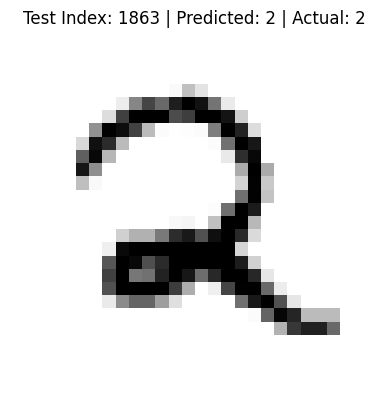

In [26]:
def predict_and_plot(dataset=test_dataset, model=model):
    # Choose a random row from test data
    idx = random.randint(0, len(dataset) - 1)
    image, label = dataset[idx]

    # Use the model to predict the label
    model.eval()
    with torch.no_grad():
        # Add batch dimension [1, 1, 28, 28]
        input_tensor = image.unsqueeze(0)
        output = model(input_tensor)
        prediction = torch.argmax(torch.softmax(output, dim=1), dim=1).item()

    # Plot the input and display prediction
    # Unnormalize for visualization
    mean, std = 0.1307, 0.3081
    unnormalized_image = image * std + mean

    plt.imshow(unnormalized_image.squeeze(), cmap='gray_r')
    plt.title(f"Test Index: {idx} | Predicted: {prediction} | Actual: {label}")
    plt.axis('off')
    plt.show()


# Run the function
predict_and_plot()

In [27]:
# save the trained model
torch.save(model.state_dict(), 'simple_cnn_model.pth')
print("Model saved to simple_cnn_model.pth")

Model saved to simple_cnn_model.pth


In [28]:
# Check if model is already defined and is a SimpleCNN instance
# Using globals() for robustness in checking if a variable exists.
if 'model' not in globals() or not isinstance(globals().get('model'), SimpleCNN):
    print("Model variable not found or not an instance of SimpleCNN, initializing model.")
    model = SimpleCNN()
else:
    print("Model variable already initialized as SimpleCNN.")

# Load the saved state dictionary
try:
    model.load_state_dict(torch.load('simple_cnn_model.pth'))
    model.eval() # Set the model to evaluation mode
    print("Model 'simple_cnn_model.pth' loaded successfully.")
except FileNotFoundError:
    print("Error: 'simple_cnn_model.pth' not found. Please ensure the model is saved first.")
except Exception as e:
    print(f"An error occurred while loading the model: {e}")

Model variable already initialized as SimpleCNN.
Model 'simple_cnn_model.pth' loaded successfully.


In [29]:
from sklearn.metrics import confusion_matrix, accuracy_score
import numpy as np
import torch

# use the final trained output to predict the test set and create a confusion matrix to display the results
model.eval() # Set the model to evaluation mode

all_preds = []
all_targets = []

with torch.no_grad():
    for data, target in test_loader:
        output = model(data)
        probs = torch.softmax(output, dim=1)
        preds = torch.argmax(probs, dim=1)

        # Extend the lists with flattened numpy arrays for each batch
        all_preds.extend(preds.numpy())
        all_targets.extend(target.numpy())

# Convert lists to numpy arrays (now they will be 1D)
all_preds = np.array(all_preds)
all_targets = np.array(all_targets)

print("Predictions made on the test dataset.")

# Calculate overall accuracy
overall_accuracy = accuracy_score(all_targets, all_preds)
print(f"Overall Test Accuracy: {overall_accuracy:.4f}")

# Generate Confusion Matrix
conf_mat = confusion_matrix(all_targets, all_preds)
print("Confusion Matrix:\n", conf_mat)

Predictions made on the test dataset.
Overall Test Accuracy: 0.9767
Confusion Matrix:
 [[ 971    0    5    0    0    1    1    1    1    0]
 [   0 1128    5    1    0    1    0    0    0    0]
 [   0    2 1026    0    0    0    0    2    2    0]
 [   0    0    4 1000    0    2    0    1    2    1]
 [   0    1    6    0  957    0    0    1    2   15]
 [   2    1    0    6    0  879    2    1    1    0]
 [   6    3    3    1    4    5  933    0    3    0]
 [   1    6   27    5    0    0    0  976    0   13]
 [   5    0   13   10    3    5    1    3  923   11]
 [   5    6    1    5    7    4    0    6    1  974]]


In [30]:
# Calculate per-class accuracy
num_classes = len(np.unique(all_targets))
class_accuracy = np.diag(conf_mat) / np.sum(conf_mat, axis=1)

print("\nPer-Class Accuracy:")
for i in range(num_classes):
    print(f"Class {i}: {class_accuracy[i]:.4f}")


Per-Class Accuracy:
Class 0: 0.9908
Class 1: 0.9938
Class 2: 0.9942
Class 3: 0.9901
Class 4: 0.9745
Class 5: 0.9854
Class 6: 0.9739
Class 7: 0.9494
Class 8: 0.9476
Class 9: 0.9653
